# Import các thư viện cần thiết


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
from pathlib import Path
from tqdm import tqdm
from typing import Dict

# Đọc dữ liệu từ file


In [3]:
raw_train_df = pd.read_json("../development/msvd_train.json")
raw_val_df = pd.read_json("../development/msvd_val.json")
raw_test_df = pd.read_json("../development/msvd_test.json")

In [4]:
raw_train_df.head()

,video_id,video,caption,source
0,WTf5EgVY5uU_98_104,WTf5EgVY5uU_98_104.avi,"[a woman breaks an egg, a woman breaks two egg...",MSVD
1,WeOU0Iba1Xg_1_30,WeOU0Iba1Xg_1_30.avi,"[a man galloping on his horse, a girl is ridin...",MSVD
2,0wutCy2ZGOQ_4_10,0wutCy2ZGOQ_4_10.avi,[several boys are playing football in a fenced...,MSVD
3,IWhrWLOAin0_1_4,IWhrWLOAin0_1_4.avi,[a large dog gets something out of a refrigera...,MSVD
4,O9cOSO9L8Zs_1_16,O9cOSO9L8Zs_1_16.avi,"[a man is swinging on a rope, a man is swingin...",MSVD


# Xác định thời lượng thực tế của các video


In [4]:
def get_video_duration(filename: str) -> float:
    """
    Ref: https://stackoverflow.com/questions/3844430/how-do-i-get-the-duration-of-a-video-in-python
    """
    result = subprocess.run(["ffprobe", "-v", "error", "-show_entries",
                             "format=duration", "-of",
                             "default=noprint_wrappers=1:nokey=1", filename],
                            stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT)
    return float(result.stdout)


# Danh sách các video .avi trong MSVD dataset
video_paths = list(Path("./data/raw/MSVD/raw_video/").glob("*.avi"))
assert len(video_paths) == 1970

# Xác định thời lượng thực tế của các video
print("Getting video durations...")
durations: Dict[str, float] = {}
for video_path in tqdm(video_paths):
    durations[video_path.stem] = get_video_duration(str(video_path))

Getting video durations...


100%|██████████| 1970/1970 [01:55<00:00, 17.00it/s]


Tạo DataFrame thể hiện thời lượng thực tế và thời lượng theo lý thuyết của các video


In [ ]:
duration_df = pd.DataFrame(durations.items(), columns=["video_id", "duration"])
duration_df["theoretical_duration"] = duration_df["video_id"].apply(
    lambda x: int(x.split("_")[-1]) - int(x.split("_")[-2]))
duration_df.to_csv("./MSVD_video_durations.csv", index=False)
duration_df.head()

,video_id,duration,theoretical_duration
0,-4wsuPCjDBc_5_15,10.027743,10
1,-7KMZQEsJW4_205_208,3.066667,3
2,-8y1Q0rA3n8_108_115,7.007000,7
3,-8y1Q0rA3n8_95_102,7.007000,7
4,-9CUm-2cui8_39_44,5.013928,5


In [15]:
duration_df = pd.read_csv("./MSVD_video_durations.csv")
duration_df["duration_diff"] = abs(duration_df["duration"] - duration_df["theoretical_duration"])
print("Statistics of duration differences (in seconds):")
duration_df.sort_values("duration_diff", ascending=False).head()

Statistics of duration differences (in seconds):


,video_id,duration,theoretical_duration,duration_diff
1903,ZK4W-2ifl6I_1_28,6.549372,27,20.450628
268,6KS8R3RxrV8_0_23,7.619772,23,15.380228
1002,K6xy6C-Hsa0_2_28,11.933148,26,14.066852
1831,yBK02O1Oewc_20_35,3.154381,15,11.845619
199,4JVpbYmqfcI_5_19,4.265162,14,9.734838


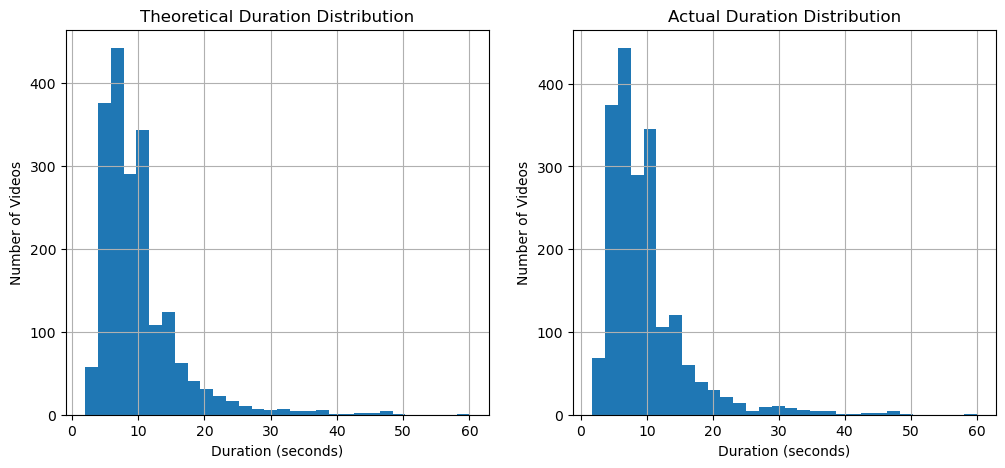

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

duration_df["theoretical_duration"].hist(bins=30, ax=ax[0])
ax[0].set_title("Theoretical Duration Distribution")
ax[0].set_xlabel("Duration (seconds)")
ax[0].set_ylabel("Number of Videos")

duration_df["duration"].hist(bins=30, ax=ax[1])
ax[1].set_title("Actual Duration Distribution")
ax[1].set_xlabel("Duration (seconds)")
ax[1].set_ylabel("Number of Videos")

plt.show()

# Phân tích thời lượng (giây) của các video ngắn


In [9]:
def duration_analysis(df: pd.DataFrame) -> None:
    # Phân tích thời lượng video
    duration_stats = df["duration"].describe()
    print("Thống kê thời lượng video:")
    print(duration_stats)
    
    # Vẽ biểu đồ phân phối thời lượng video
    plt.figure(figsize=(10, 6))
    plt.hist(df["duration"], bins=30, color='lightblue', alpha=0.7, edgecolor='black')
    plt.axvline(df["duration"].mean(), color='red', linestyle='dashed', linewidth=1)
    plt.axvline(df["duration"].median(), color='green', linestyle='dashed', linewidth=1)
    plt.legend({'Mean': df["duration"].mean(), 'Median': df["duration"].median()})
    plt.title("Phân phối thời lượng video")
    plt.xlabel("Thời gian (giây)")
    plt.ylabel("Số lượng video")
    plt.grid(axis='y', alpha=0.75)
    plt.show()

- Train set:


Thống kê thời lượng video:
count    1200.000000
mean        9.267136
std         5.492677
min         2.005571
25%         6.006000
50%         8.008000
75%        10.061577
max        47.447400
Name: duration, dtype: float64


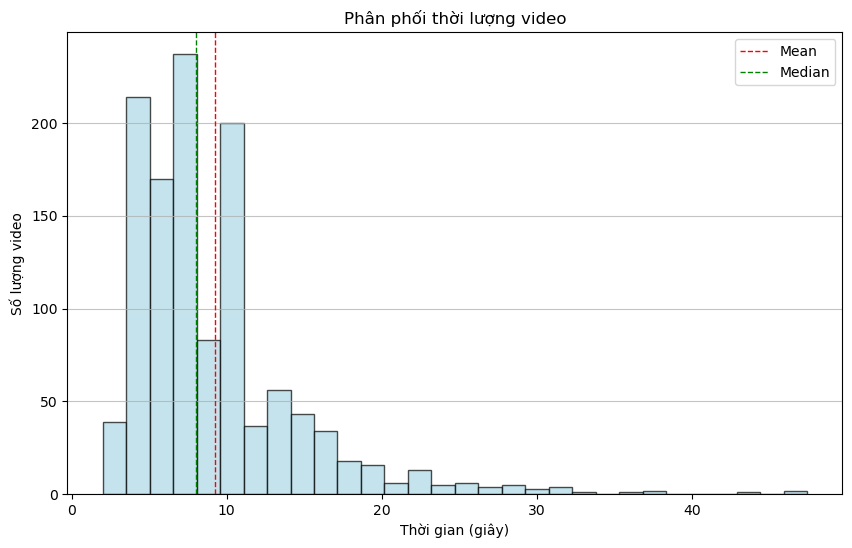

In [18]:
# Merge duration_df với train_df để phân tích
train_df = raw_train_df.merge(duration_df, on="video_id", how="left")
duration_analysis(train_df)

- Validation set:


Thống kê thời lượng video:
count    100.000000
mean      11.575190
std        7.316571
min        1.735067
25%        7.611803
50%       10.033333
75%       13.290000
max       48.033333
Name: duration, dtype: float64


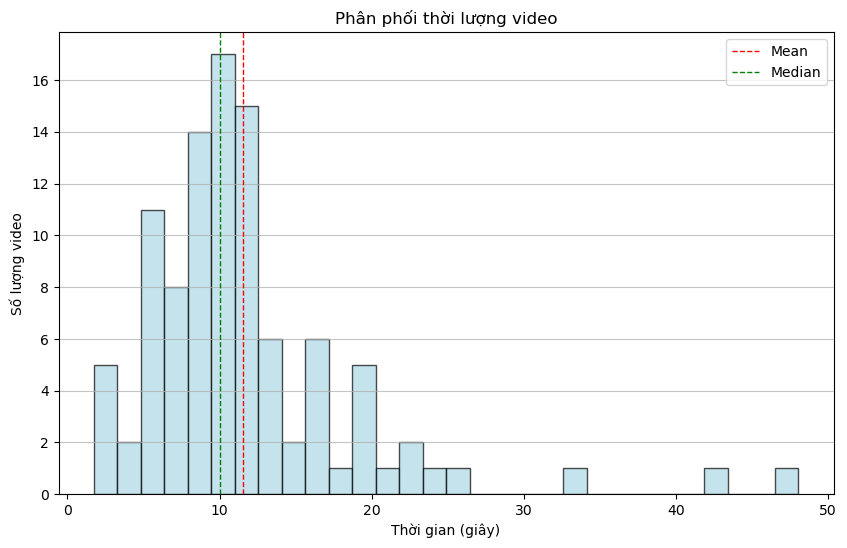

In [19]:
val_df = raw_val_df.merge(duration_df, on="video_id", how="left")
duration_analysis(val_df)

- Test set:

Thống kê thời lượng video:
count    670.000000
mean      10.039399
std        7.032851
min        1.866667
25%        6.006000
50%        8.033333
75%       11.041250
max       60.026633
Name: duration, dtype: float64


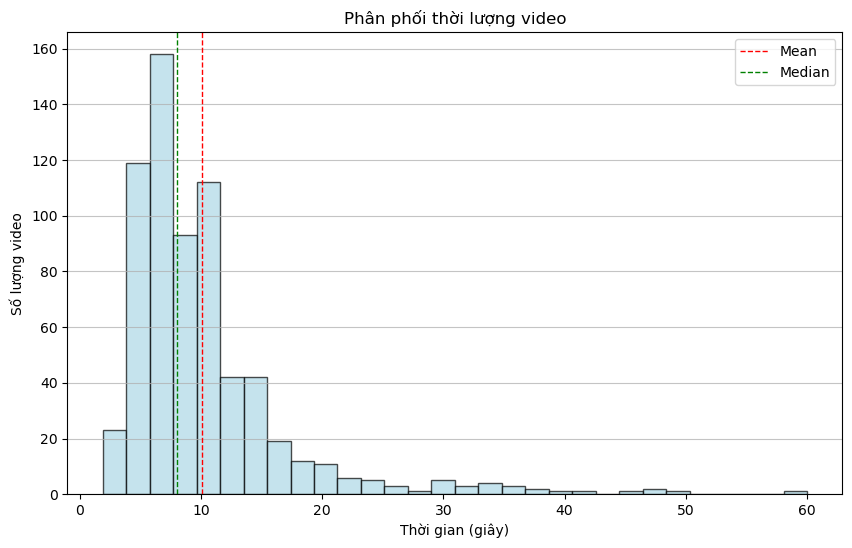

In [20]:
test_df = raw_test_df.merge(duration_df, on="video_id", how="left")
duration_analysis(test_df)

**Nhận xét:**

- Video ngắn nhất trong cả 3 tập dữ liệu có thời lượng khoảng 2 giây.

- Thời lượng trung bình và trung vị của hầu hết các video trong cả 3 tập dữ liệu rơi vào khoảng 10 giây, với độ lệch chuẩn khoảng 7-8 giây. Điều này cho thấy rằng hầu hết các video đều có thời lượng ngắn, phù hợp với định dạng của video ngắn.


# Phân tích độ dài caption của các video ngắn


In [21]:
def caption_length_analysis(df: pd.DataFrame) -> None:
    # Tách một danh sách các caption từ DataFrame thành một Series
    caption_ser = df["caption"].explode()
    # Tính độ dài của mỗi caption
    caption_lengths = caption_ser.str.len()
    
    # Tính thống kê độ dài caption
    length_stats = caption_lengths.describe()
    print("Thống kê độ dài caption:")
    print(length_stats)
    
    # Vẽ biểu đồ phân phối độ dài caption
    plt.figure(figsize=(10, 6))
    plt.hist(caption_lengths, bins=30, color='coral', alpha=0.7, edgecolor='black')
    plt.axvline(caption_lengths.mean(), color='red', linestyle='dashed', linewidth=1)
    plt.axvline(caption_lengths.median(), color='green', linestyle='dashed', linewidth=1)
    plt.legend({'Mean': caption_lengths.mean(), 'Median': caption_lengths.median()})
    plt.title("Phân phối độ dài caption")
    plt.xlabel("Độ dài caption (ký tự)")
    plt.ylabel("Số lượng caption")
    plt.grid(axis='y', alpha=0.75)
    plt.show()

- Train set:

Thống kê độ dài caption:
count    48774.000000
mean        33.757330
std         13.813957
min          2.000000
25%         25.000000
50%         31.000000
75%         39.000000
max        221.000000
Name: caption, dtype: float64


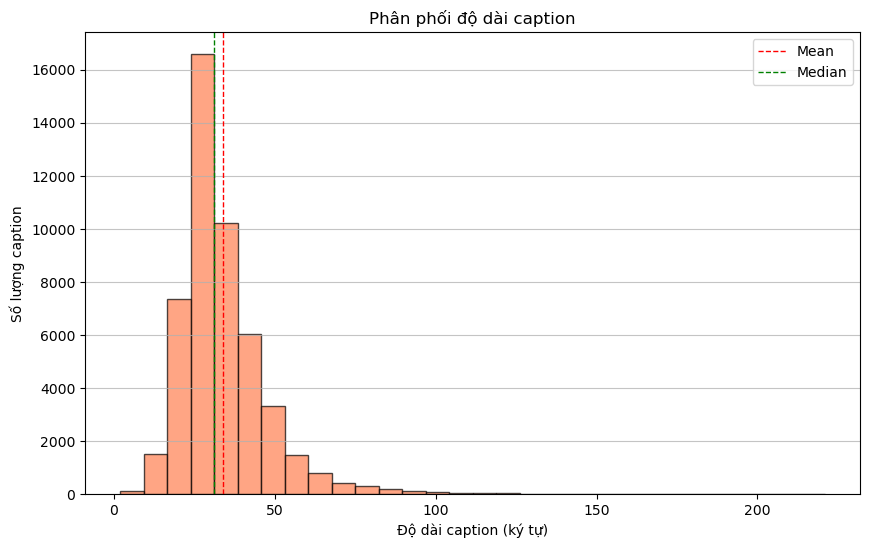

In [22]:
caption_length_analysis(train_df)

- Validation set:

Thống kê độ dài caption:
count    4290.000000
mean       33.742424
std        14.102747
min         3.000000
25%        25.000000
50%        31.000000
75%        39.000000
max       134.000000
Name: caption, dtype: float64


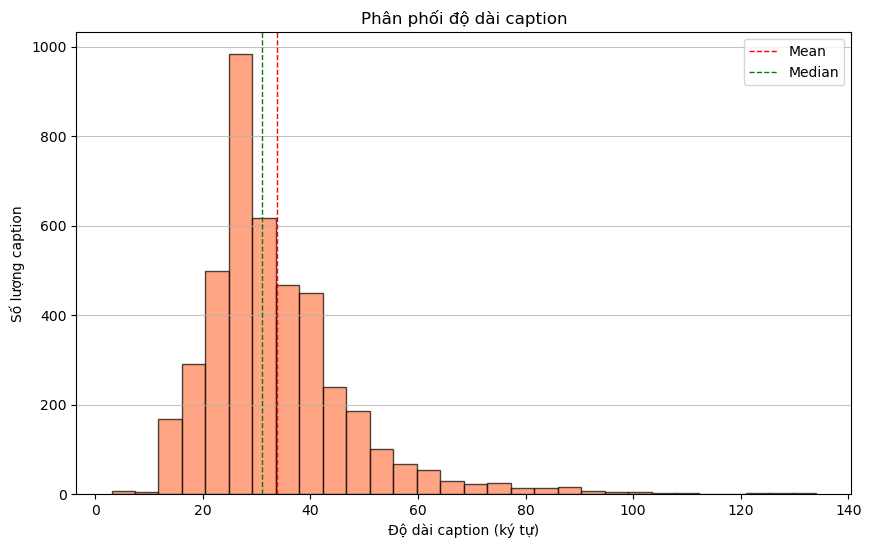

In [23]:
caption_length_analysis(val_df)

- Test set:

Thống kê độ dài caption:
count    27763.000000
mean        33.824154
std         14.044127
min          2.000000
25%         25.000000
50%         31.000000
75%         39.000000
max        216.000000
Name: caption, dtype: float64


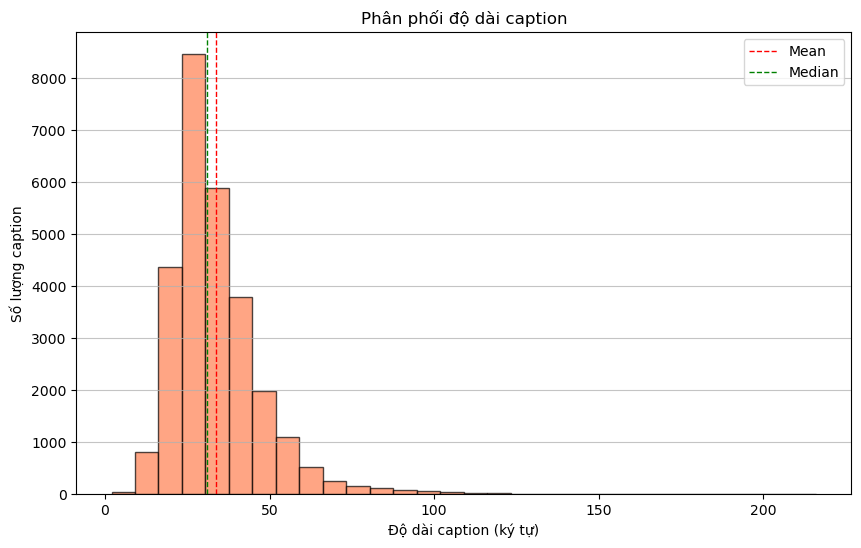

In [24]:
caption_length_analysis(test_df)

**Nhận xét:**

- Độ dài trung bình và trung vị của các caption trong cả 3 tập dữ liệu rơi vào khoảng 30 từ, với độ lệch chuẩn khoảng 14 từ. Điều này cho thấy rằng hầu hết các caption đều có độ dài tương đối ngắn, phù hợp với định dạng của video ngắn.

- Có một vài caption có độ dài vượt quá 100 từ, nhưng chúng chiếm tỷ lệ rất nhỏ. Điều này có thể do một số caption được viết dài hơn để mô tả chi tiết hơn về nội dung video.


# Split features into train, val, test sets based on video IDs


In [1]:
import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm

# Load the train, validation, and test DataFrames
train_df = pd.read_json("./msvd_train.json")
val_df = pd.read_json("./msvd_val.json")
test_df = pd.read_json("./msvd_test.json")
train_video_ids = set(train_df["video_id"].tolist())
val_video_ids = set(val_df["video_id"].tolist())
test_video_ids = set(test_df["video_id"].tolist())

# === Define the feature type and paths ===
corpus = "MSVD"
# feature_type = "newBlip2ClsKF"
# feature_type = "newMViTv2"
# feature_type = "newNormMViTv2"
# feature_type = "newImgCapBlip2KF"
for feature_type in ["newBlip2ClsKF", "newMViTv2", "newImgCapBlip2KF"]:
    print(f"========== Processing feature type: {feature_type} ==========")
    total_feature_path = f"../../data/{corpus}/features/{corpus}_{feature_type}.hdf5"
    train_feature_path = f"../../data/{corpus}/features/{corpus}_{feature_type}_train.hdf5"
    val_feature_path   = f"../../data/{corpus}/features/{corpus}_{feature_type}_val.hdf5"
    test_feature_path  = f"../../data/{corpus}/features/{corpus}_{feature_type}_test.hdf5"

    train_features = {}
    test_features = {}
    val_features = {}

    # Split the features into train, validation, and test sets
    #   based on the video IDs in the respective DataFrames
    print("Splitting features into train, validation, and test sets...")
    with h5py.File(total_feature_path, "r") as f:
        assert len(f.keys()) == 1970
        for key in tqdm(f.keys(), desc="Splitting features"):
            assert len(f[key].shape) == 2
            if   key in train_video_ids: train_features[key] = f[key][:]
            elif key in val_video_ids:   val_features[key] = f[key][:]
            elif key in test_video_ids:  test_features[key] = f[key][:]
            else: raise ValueError(f"Unexpected video ID: {key}")

    with h5py.File(train_feature_path, "w") as f:
        for key, value in train_features.items():
            f.create_dataset(key, data=value)
    with h5py.File(val_feature_path, "w") as f:
        for key, value in val_features.items():
            f.create_dataset(key, data=value)
    with h5py.File(test_feature_path, "w") as f:
        for key, value in test_features.items():
            f.create_dataset(key, data=value)

    # Verify the splits
    with h5py.File(train_feature_path, "r") as f:
        print(f"Number of training videos: {len(f.keys())}")
    with h5py.File(val_feature_path, "r") as f:
        print(f"Number of validation videos: {len(f.keys())}")
    with h5py.File(test_feature_path, "r") as f:
        print(f"Number of test videos: {len(f.keys())}")

========== Processing feature type: newBlip2ClsKF ==========
Splitting features into train, validation, and test sets...


Splitting features: 100%|██████████| 1970/1970 [00:01<00:00, 1455.03it/s]


Number of training videos: 1200
Number of validation videos: 100
Number of test videos: 670
========== Processing feature type: newMViTv2 ==========
Splitting features into train, validation, and test sets...


Splitting features: 100%|██████████| 1970/1970 [00:01<00:00, 1807.53it/s]


Number of training videos: 1200
Number of validation videos: 100
Number of test videos: 670
========== Processing feature type: newImgCapBlip2KF ==========
Splitting features into train, validation, and test sets...


Splitting features: 100%|██████████| 1970/1970 [00:01<00:00, 1694.31it/s]


Number of training videos: 1200
Number of validation videos: 100
Number of test videos: 670


In [2]:
import pandas as pd

gop_df = pd.read_csv("./msvd_new_gop_counts.csv")
keyframe_df = pd.read_csv("./msvd_new_keyframe_counts.csv")
merge_df = pd.merge(gop_df, keyframe_df, on="video_id", how="outer")
merge_df.head()

,video_id,gop_count,keyframe_count
0,-4wsuPCjDBc_5_15,9,9
1,-7KMZQEsJW4_205_208,3,3
2,-8y1Q0rA3n8_108_115,7,7
3,-8y1Q0rA3n8_95_102,7,7
4,-9CUm-2cui8_39_44,5,5


In [3]:
(merge_df['gop_count'] == merge_df['keyframe_count']).sum()

1970

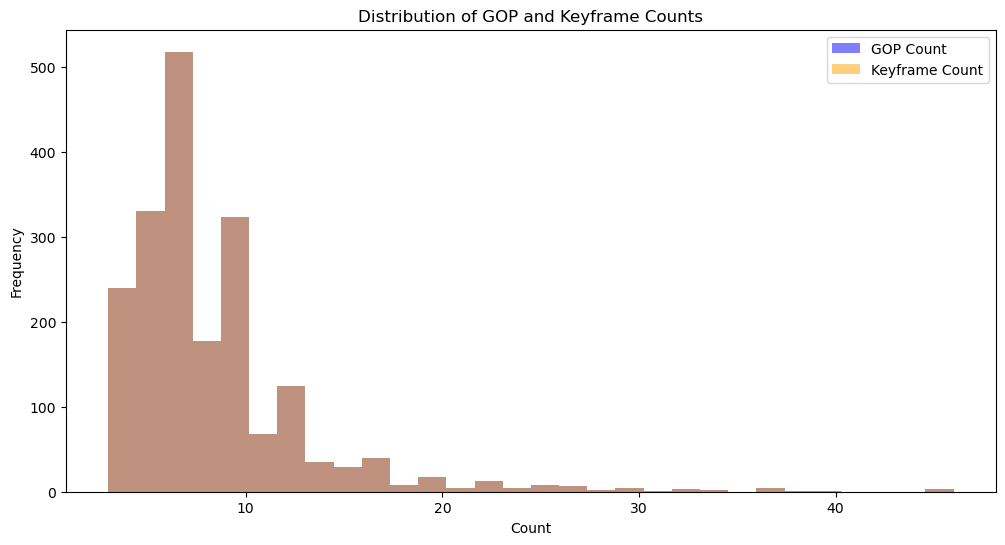

In [4]:
# Plot the distribution of GOP and keyframe counts
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(merge_df['gop_count'], bins=30, alpha=0.5,label='GOP Count', color='blue')
plt.hist(merge_df['keyframe_count'], bins=30, alpha=0.5,label='Keyframe Count', color='orange')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.title('Distribution of GOP and Keyframe Counts')
plt.legend()
plt.show()

In [5]:
merge_df.describe()

,gop_count,keyframe_count
count,1970.000000,1970.000000
mean,8.325381,8.325381
std,4.813665,4.813665
min,3.000000,3.000000
25%,5.000000,5.000000
50%,7.000000,7.000000
75%,10.000000,10.000000
max,46.000000,46.000000


- #GOP Analysis on Train Set:


In [6]:
import pandas as pd

train_df = pd.read_json("./msvd_train.json")
train_video_ids = set(train_df["video_id"].tolist())
gop_df = pd.read_csv("./msvd_new_gop_counts.csv")
train_df = gop_df[gop_df["video_id"].isin(train_video_ids)]
train_df.describe()

,gop_count
count,1200.000000
mean,8.057500
std,4.399279
min,3.000000
25%,5.000000
50%,7.000000
75%,9.000000
max,46.000000


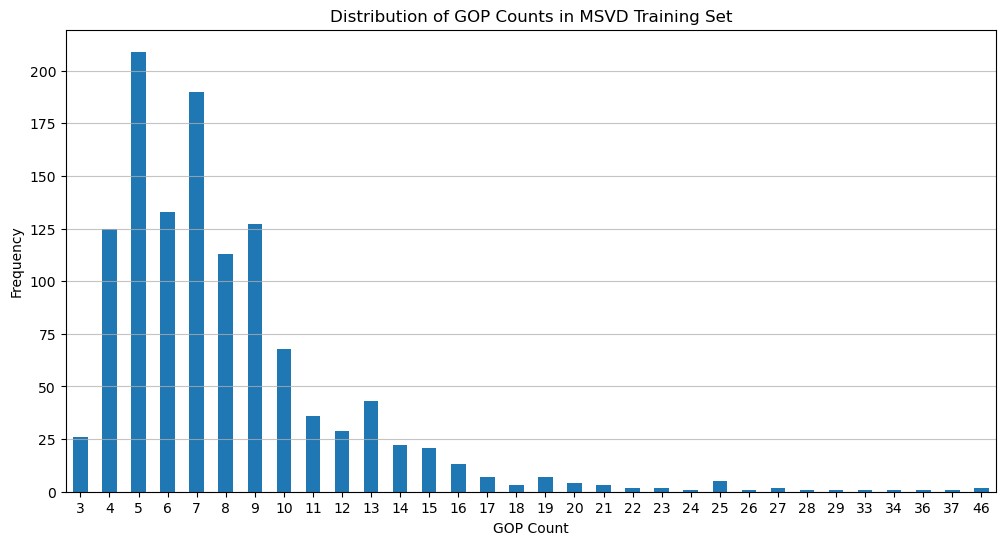

In [7]:
from matplotlib import pyplot as plt
train_df["gop_count"].value_counts().sort_index().plot(kind="bar", figsize=(12, 6))
plt.xlabel("GOP Count")
plt.ylabel("Frequency")
plt.title("Distribution of GOP Counts in MSVD Training Set")
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=0)
plt.show()

In [8]:
print(train_df["gop_count"].quantile([0.25, 0.50, 0.75, 0.85, 0.95]))

0.25     5.0
0.50     7.0
0.75     9.0
0.85    11.0
0.95    15.0
Name: gop_count, dtype: float64


# Phân tích số lượng keyframe (I-frame) trong các video ngắn


In [1]:
import av
import os

# Tạo thư mục để lưu frame
output_dir = "keyframes"
os.makedirs(output_dir, exist_ok=True)

# Mở file video
container = av.open('./data/raw/MSVD/raw_video/_WRC7HXBJpU_386_391.avi')

print("Bắt đầu trích xuất I-frame...")
frame_count = 0

# Lặp qua các frame trong stream video
# Chúng ta decode stream video chính (thường là stream 0)
for frame in container.decode(video=0):
    
    # Kiểm tra cờ frame.key_frame
    # I-frame sẽ có cờ này là True
    if frame.key_frame:
        frame_count += 1
        print(f"Phát hiện I-frame tại PTS: {frame.pts}")
        
        # Lưu frame thành file ảnh (ví dụ: PNG)
        img = frame.to_image() # Chuyển đổi thành PIL Image
        print(img)
        # output_filename = os.path.join(output_dir, f"keyframe-{frame_count:04d}.png")
        # img.save(output_filename)

print(f"Đã trích xuất và lưu tổng cộng {frame_count} I-frame.")
container.close()

Bắt đầu trích xuất I-frame...
Phát hiện I-frame tại PTS: 1
<PIL.Image.Image image mode=RGB size=1280x720 at 0x7F862D5C3D90>
Phát hiện I-frame tại PTS: 61
<PIL.Image.Image image mode=RGB size=1280x720 at 0x7F8611B75650>
Phát hiện I-frame tại PTS: 121
<PIL.Image.Image image mode=RGB size=1280x720 at 0x7F8611B7D690>
Đã trích xuất và lưu tổng cộng 3 I-frame.


In [36]:
import av
from pathlib import Path
from typing import Dict
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def count_keyframes(video_path: str) -> int:
    """
    Đếm số lượng I-frame trong một video sử dụng PyAV.
    """
    container = av.open(video_path)
    keyframe_count = 0

    for frame in container.decode(video=0):
        if frame.key_frame:
            keyframe_count += 1

    container.close()
    return keyframe_count


# Danh sách các video .avi trong MSVD dataset
video_paths = list(Path("./data/raw/MSVD/raw_video/").glob("*.avi"))
assert len(video_paths) == 1970

# Đếm số lượng I-frame trong mỗi video
print("Counting keyframes in videos...")
keyframe_counts: Dict[str, int] = {}
for video_path in tqdm(video_paths):
    keyframe_counts[video_path.stem] = count_keyframes(str(video_path))

Counting keyframes in videos...


100%|██████████| 1970/1970 [16:01<00:00,  2.05it/s]


In [40]:
keyframe_df = pd.DataFrame(keyframe_counts.items(), columns=["video_id", "keyframe_count"])
keyframe_df.head()

,video_id,keyframe_count
0,-4wsuPCjDBc_5_15,12
1,-7KMZQEsJW4_205_208,1
2,-8y1Q0rA3n8_108_115,5
3,-8y1Q0rA3n8_95_102,5
4,-9CUm-2cui8_39_44,4


In [48]:
keyframe_df.to_csv("./MSVD_keyframe_counts.csv", index=False)

In [41]:
def keyframe_count_analysis(df: pd.DataFrame) -> None:
    # Tính thống kê số lượng I-frame
    count_stats = df["keyframe_count"].describe()
    print("Thống kê số lượng I-frame:")
    print(count_stats)
    
    # Vẽ biểu đồ phân phối số lượng I-frame
    plt.figure(figsize=(10, 6))
    plt.hist(df["keyframe_count"], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
    plt.axvline(df["keyframe_count"].mean(), color='red', linestyle='dashed', linewidth=1)
    plt.axvline(df["keyframe_count"].median(), color='green', linestyle='dashed', linewidth=1)
    plt.legend({'Mean': df["keyframe_count"].mean(), 'Median': df["keyframe_count"].median()})
    plt.title("Phân phối số lượng I-frame trong video")
    plt.xlabel("Số lượng I-frame")
    plt.ylabel("Số lượng video")
    plt.grid(axis='y', alpha=0.75)
    plt.show()

- Train set:

Thống kê số lượng I-frame:
count    1200.000000
mean        6.792500
std         5.031952
min         1.000000
25%         4.000000
50%         5.000000
75%         8.000000
max        45.000000
Name: keyframe_count, dtype: float64


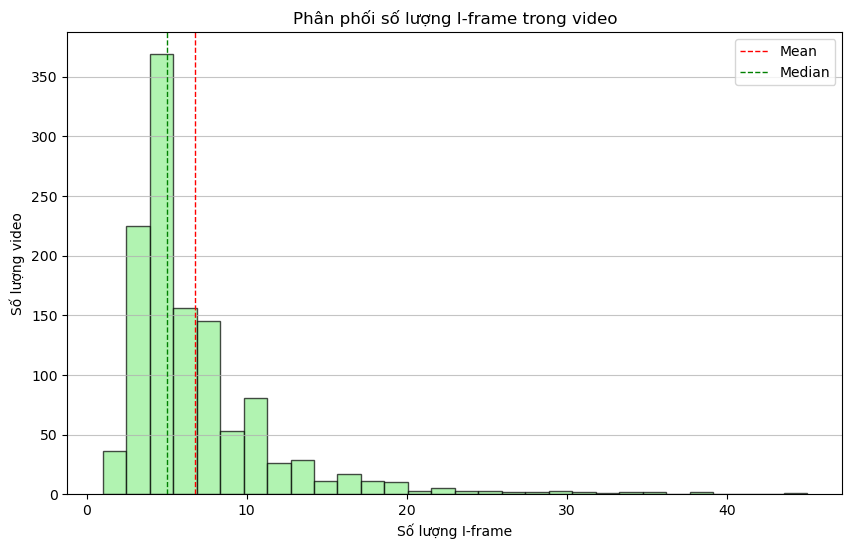

In [42]:
train_df = raw_train_df.merge(keyframe_df, on="video_id", how="left")
keyframe_count_analysis(train_df)

- Validation set:

Thống kê số lượng I-frame:
count    100.000000
mean       8.340000
std        6.169688
min        2.000000
25%        5.000000
50%        6.000000
75%        9.250000
max       36.000000
Name: keyframe_count, dtype: float64


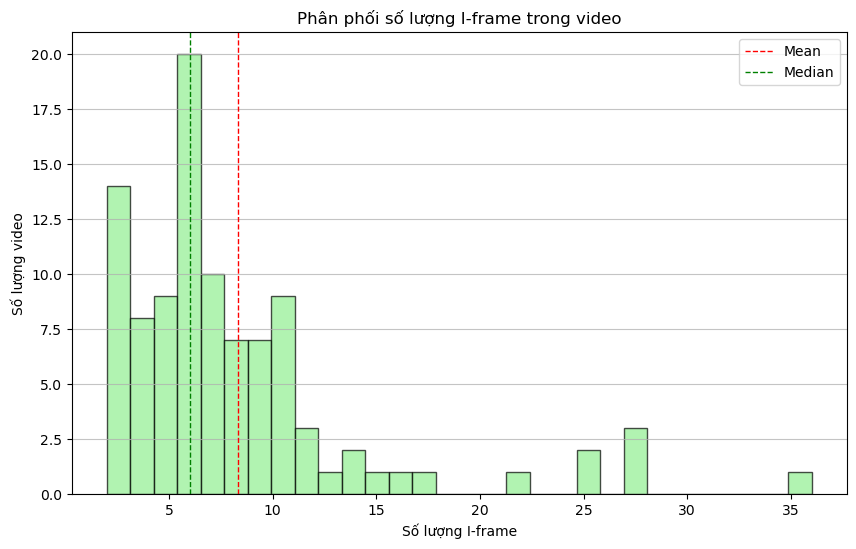

In [43]:
val_df = raw_val_df.merge(keyframe_df, on="video_id", how="left")
keyframe_count_analysis(val_df)

- Test set:

Thống kê số lượng I-frame:
count    670.000000
mean       7.459701
std        6.267387
min        2.000000
25%        4.000000
50%        6.000000
75%        9.000000
max       82.000000
Name: keyframe_count, dtype: float64


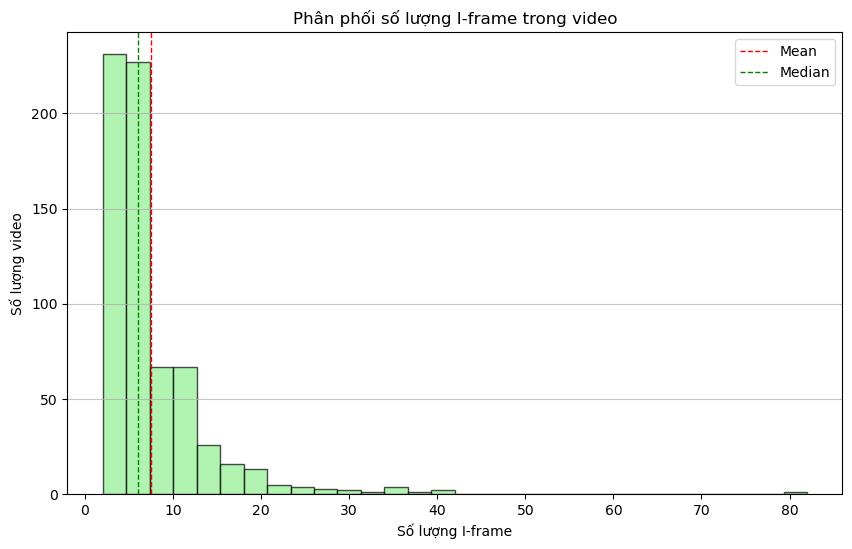

In [44]:
test_df = raw_test_df.merge(keyframe_df, on="video_id", how="left")
keyframe_count_analysis(test_df)

# Phân tích số lượng motion group trong các video

In [5]:
keyframe_df = pd.read_csv("./MSVD_keyframe_counts.csv")
keyframe_df.head()

,video_id,keyframe_count
0,-4wsuPCjDBc_5_15,12
1,-7KMZQEsJW4_205_208,1
2,-8y1Q0rA3n8_108_115,5
3,-8y1Q0rA3n8_95_102,5
4,-9CUm-2cui8_39_44,4


In [6]:
import h5py

with h5py.File("./data/MSVD/features/MSVD_I3DRaft.hdf5", "r") as f:
    print(f"Number of videos in I3D features: {len(f.keys())}")
    
    # Thêm cột mới motion_group vào keyframe_df
    keyframe_df["motion_group"] = -1
    for key in f.keys():
        keyframe_df.loc[keyframe_df["video_id"] == key, "motion_group"] = f[key].shape[0]

Number of videos in I3D features: 1970


In [7]:
keyframe_df.head()

,video_id,keyframe_count,motion_group
0,-4wsuPCjDBc_5_15,12,5
1,-7KMZQEsJW4_205_208,1,1
2,-8y1Q0rA3n8_108_115,5,4
3,-8y1Q0rA3n8_95_102,5,4
4,-9CUm-2cui8_39_44,4,3


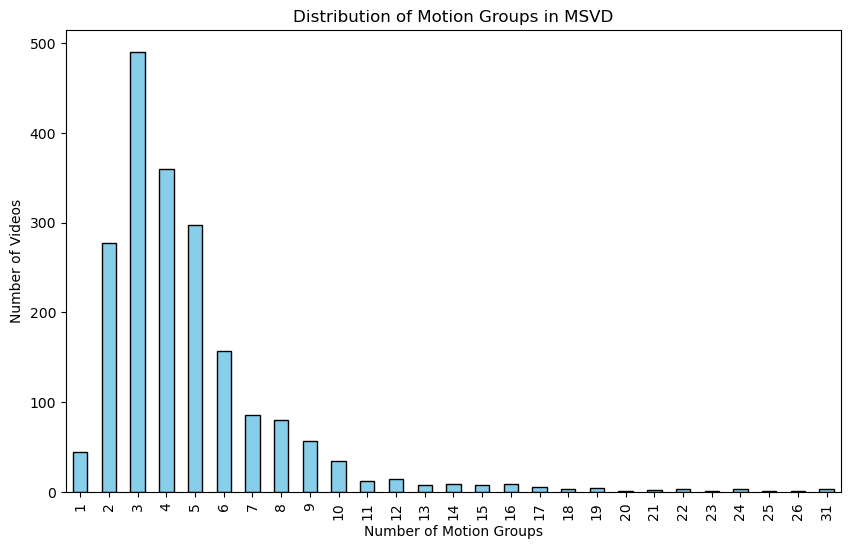

In [8]:
# Plot histogram of motion groups
plt.figure(figsize=(10, 6))
keyframe_df["motion_group"].value_counts().sort_index().plot(kind="bar", color='skyblue', edgecolor='black')
plt.title("Distribution of Motion Groups in MSVD")
plt.xlabel("Number of Motion Groups")
plt.ylabel("Number of Videos")
plt.show()

In [9]:
keyframe_df["motion_group"].describe()

count    1970.000000
mean        4.780711
std         3.233998
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        31.000000
Name: motion_group, dtype: float64

In [12]:
keyframe_df["motion_group"].describe()

count    1970.000000
mean        3.772589
std         3.030413
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        28.000000
Name: motion_group, dtype: float64

# Test PyTorch methods


In [1]:
import torch
import numpy as np

x1 = torch.randn(64, 10, 512)
x2 = torch.randn(64, 10, 512)
x3 = torch.randn(64, 10, 512)

# ans = x1[:,0,:] + x2[:,0,:] + x3[:,0,:]
(x1[:,0,:] + x2[:,0,:] + x3[:,0,:]).unsqueeze(1).shape

torch.Size([64, 1, 512])

In [10]:
a_np = np.ones((6, 10))
print(a_np.shape)
print(f"len(a_np): {len(a_np)}")

num_tokens = 10
num_padding = num_tokens - a_np.shape[0]
print(f"num_padding: {num_padding}")

# zero padding
pad_np = np.zeros((num_padding, a_np.shape[1]), dtype=a_np.dtype)
print(f"pad_np.shape: {pad_np.shape}")

# Concatenate the original array with the padding
padded_np = np.concatenate((a_np, pad_np), axis=0)
print(f"padded_np.shape: {padded_np.shape}")
padded_np

(6, 10)
len(a_np): 6
num_padding: 4
pad_np.shape: (4, 10)
padded_np.shape: (10, 10)


array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [2]:
import torch

# x1 = torch.arange(30).reshape(3,2,5)
# x2 = torch.arange(30).reshape(3,2,5)
# x3 = torch.arange(30).reshape(3,2,5)

x1 = torch.full((3,2,5), 1)
x2 = torch.full((3,2,5), 2)
x3 = torch.full((3,2,5), 3)
stacked = torch.stack([x1, x2, x3], dim=2)
print(f"stacked.shape={stacked.shape}")
B, T, D = x1.shape
out = stacked.reshape(B, -1, D)
out.shape, out

stacked.shape=torch.Size([3, 2, 3, 5])


(torch.Size([3, 6, 5]),
 tensor([[[1, 1, 1, 1, 1],
          [2, 2, 2, 2, 2],
          [3, 3, 3, 3, 3],
          [1, 1, 1, 1, 1],
          [2, 2, 2, 2, 2],
          [3, 3, 3, 3, 3]],
 
         [[1, 1, 1, 1, 1],
          [2, 2, 2, 2, 2],
          [3, 3, 3, 3, 3],
          [1, 1, 1, 1, 1],
          [2, 2, 2, 2, 2],
          [3, 3, 3, 3, 3]],
 
         [[1, 1, 1, 1, 1],
          [2, 2, 2, 2, 2],
          [3, 3, 3, 3, 3],
          [1, 1, 1, 1, 1],
          [2, 2, 2, 2, 2],
          [3, 3, 3, 3, 3]]]))

In [3]:
assert torch.equal(out[:,0::3,:],x1[:,:,:]) == True
assert torch.equal(out[:,1::3,:],x2[:,:,:]) == True
assert torch.equal(out[:,2::3,:],x3[:,:,:]) == True

In [4]:
x1 = torch.arange(30).reshape(3,2,5)
x2 = torch.arange(30).reshape(3,2,5)
x3 = torch.arange(30).reshape(3,2,5)
out = torch.cat([x1, x2, x3], dim=1)
out.shape, out

(torch.Size([3, 6, 5]),
 tensor([[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9]],
 
         [[10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],
 
         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29],
          [20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29],
          [20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29]]]))

In [5]:
assert torch.equal(out[0, 0, :], x1[0, 0, :]) == True
assert torch.equal(out[0, 1, :], x2[0, 0, :]) == True
assert torch.equal(out[0, 2, :], x3[0, 0, :]) == True
assert torch.equal(out[0, 3, :], x1[0, 1, :]) == True
assert torch.equal(out[0, 4, :], x2[0, 1, :]) == True
assert torch.equal(out[0, 5, :], x3[0, 1, :]) == True

AssertionError: 

In [30]:
mask_1 = torch.full((3, 5), True)
mask_2 = torch.full((3, 5), True)
mask_3 = torch.full((3, 5), False)
mask_1 | mask_2 | mask_3

tensor([[True, True, True, True, True],
        [True, True, True, True, True],
        [True, True, True, True, True]])

In [31]:
mask_1 = torch.full((3, 5), True)
mask_1[:,0] = False
mask_1 = mask_1.unsqueeze(1)
mask_1.shape, mask_1

(torch.Size([3, 1, 5]),
 tensor([[[False,  True,  True,  True,  True]],
 
         [[False,  True,  True,  True,  True]],
 
         [[False,  True,  True,  True,  True]]]))

In [32]:
x1 = torch.full((3, 5, 4), 1)
x1.shape, x1

(torch.Size([3, 5, 4]),
 tensor([[[1, 1, 1, 1],
          [1, 1, 1, 1],
          [1, 1, 1, 1],
          [1, 1, 1, 1],
          [1, 1, 1, 1]],
 
         [[1, 1, 1, 1],
          [1, 1, 1, 1],
          [1, 1, 1, 1],
          [1, 1, 1, 1],
          [1, 1, 1, 1]],
 
         [[1, 1, 1, 1],
          [1, 1, 1, 1],
          [1, 1, 1, 1],
          [1, 1, 1, 1],
          [1, 1, 1, 1]]]))

In [33]:
x1 * mask_1.squeeze(1).unsqueeze(-1).to(x1.dtype)

tensor([[[0, 0, 0, 0],
         [1, 1, 1, 1],
         [1, 1, 1, 1],
         [1, 1, 1, 1],
         [1, 1, 1, 1]],

        [[0, 0, 0, 0],
         [1, 1, 1, 1],
         [1, 1, 1, 1],
         [1, 1, 1, 1],
         [1, 1, 1, 1]],

        [[0, 0, 0, 0],
         [1, 1, 1, 1],
         [1, 1, 1, 1],
         [1, 1, 1, 1],
         [1, 1, 1, 1]]])

In [109]:
assert torch.equal(out[:,0::3], mask_1[:,:]) == True
assert torch.equal(out[:,1::3], mask_2[:,:]) == True
assert torch.equal(out[:,2::3], mask_3[:,:]) == True

In [89]:
mask_1#.shape

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

In [70]:
assert torch.equal(out[0,:,0::3], mask_1[:,:]) == True

AssertionError: 

In [25]:
x = torch.arange(10).view(1, 10, 1)
x

tensor([[[0],
         [1],
         [2],
         [3],
         [4],
         [5],
         [6],
         [7],
         [8],
         [9]]])

In [26]:
ans = (x[:,:,0] != 0)
print(ans)
assert torch.all(ans) == True

tensor([[False,  True,  True,  True,  True,  True,  True,  True,  True,  True]])


AssertionError: 

In [17]:
ans == 0

tensor([[ True, False, False, False, False, False, False, False, False, False]])

In [9]:
type(x1) == torch.Tensor

True

In [12]:
a = np.random.rand(1,2)
type(a) == np.ndarray

True

In [14]:
a.ndim 

2

In [42]:
np.linspace(0, len(range(40))-1, 10, dtype=int)

array([ 0,  4,  8, 13, 17, 21, 26, 30, 34, 39])

In [3]:
torch.cat([x1, x2, x3], dim=2).shape

torch.Size([64, 10, 1536])

In [9]:
(x1 + x2 + x3).mean(dim=1, keepdim=True).shape

torch.Size([64, 1, 512])

In [35]:
import torch.nn as nn

cls_token = nn.Parameter(torch.randn(1, 1, 512))
cls_token.mean(dim=-1)

tensor([[0.0295]], grad_fn=<MeanBackward1>)

In [36]:
cls_tokens = cls_token.expand(64, -1, -1)
cls_tokens.shape

torch.Size([64, 1, 512])

In [37]:
x1.shape

torch.Size([64, 10, 512])

In [38]:
x = torch.cat((cls_tokens, x1), dim=1)
x.shape

torch.Size([64, 11, 512])

In [47]:
all(x[1,0,:] == cls_tokens[1,0,:])  # True

True

In [48]:
x1.size(0)

64

In [51]:
False == 0

True

In [57]:
mask = torch.full((64, 1, 10), (1 != 0))
mask.shape

torch.Size([64, 1, 10])

In [65]:
ext_mask = ~mask[:,:,:1]
ext_mask.shape

torch.Size([64, 1, 1])

In [66]:
full_mask = torch.cat((ext_mask, mask), dim=2)
full_mask.shape

torch.Size([64, 1, 11])

In [73]:
full_mask.shape == (None, 1, 11)

False

In [76]:
full_mask.shape[1:] == (1, 11)

True

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class ThreeFeatureDataset(Dataset):
    def __init__(self, n=100):
        self.n = n

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        # 3 tensors có kích thước cố định theo yêu cầu
        t1 = [torch.randn(3, 2)]    # tensor 1: [5, 512]
        t2 = [torch.randn(3, 4)]   # tensor 2: [10, 768]
        t3 = [torch.randn(3, 6)]    # tensor 3: [5, 128]
        # label = torch.randint(0, 10, (1,)).item()  # ví dụ label multiclass 0..9
        label = [0,1,2,3]
        return t1, t2, t3, label

def collate_three_features(batch):
    t1, t2, t3, labels = zip(*batch)
    # return t1, t2, t3, labels
    
    print(f"type(t1)={type(t1)}, len(t1)={len(t1)}") 
    # type(t1)=<class 'tuple'>, len(t1)=4
    
    t1_list = zip(*t1)
    for idx, item in enumerate(t1):
        print(f"--- item {idx} ---")
        print(f"type(item)={type(item)}, len(item)={len(item)}")
        # type(item)=<class 'list'>, len(item)=1
        print(f"type(item[0])={type(item[0])}, item[0].shape={item[0].shape}")
        
        ans = torch.stack(item)
        print(f"ans.shape={ans.shape}")
    
    print("----- Final stacking -----")
    final_ans = torch.stack(zip(*t1))
    print(f"final_ans.shape={final_ans.shape}")

    # batch là list của tuples (t1, t2, t3, label)
    t1_list = torch.stack(t1)  # list of tensors shape [5,512]
    t2_list = torch.stack(t2)  # list of tensors shape [10,768]
    t3_list = torch.stack(t3)  # list of tensors shape [5,128]
    labels = torch.tensor(labels, dtype=torch.long)
    return t1_list, t2_list, t3_list, labels
    

dataset = ThreeFeatureDataset(n=100)
loader = DataLoader(dataset, batch_size=4, collate_fn=collate_three_features, shuffle=True)

# Example training loop consumption
for t1_list, t2_list, t3_list, labels in loader:
    # t1_list, t2_list, t3_list: lists of length batch_size
    # mỗi phần tử là tensor kích thước cố định trong ví dụ này
    # Cách xử lý phổ biến:
    # 1) xử lý riêng từng loại đặc trưng bằng module tương ứng
    # 2) pooling hoặc project về vector cố định rồi concat/stack
    break

type(t1)=<class 'tuple'>, len(t1)=4
--- item 0 ---
type(item)=<class 'list'>, len(item)=1
type(item[0])=<class 'torch.Tensor'>, item[0].shape=torch.Size([3, 2])
ans.shape=torch.Size([1, 3, 2])
--- item 1 ---
type(item)=<class 'list'>, len(item)=1
type(item[0])=<class 'torch.Tensor'>, item[0].shape=torch.Size([3, 2])
ans.shape=torch.Size([1, 3, 2])
--- item 2 ---
type(item)=<class 'list'>, len(item)=1
type(item[0])=<class 'torch.Tensor'>, item[0].shape=torch.Size([3, 2])
ans.shape=torch.Size([1, 3, 2])
--- item 3 ---
type(item)=<class 'list'>, len(item)=1
type(item[0])=<class 'torch.Tensor'>, item[0].shape=torch.Size([3, 2])
ans.shape=torch.Size([1, 3, 2])
----- Final stacking -----


TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not zip

In [68]:
import torch
from torch.utils.data import Dataset, DataLoader

class ThreeFeatureDataset(Dataset):
    def __init__(self, n=100):
        self.n = n

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        # 3 tensors có kích thước cố định theo yêu cầu
        t1 = torch.randn(3, 2)    # tensor 1: [5, 512]
        t2 = torch.randn(3, 4)   # tensor 2: [10, 768]
        t3 = torch.randn(3, 6)    # tensor 3: [5, 128]
        # label = torch.randint(0, 10, (1,)).item()  # ví dụ label multiclass 0..9
        label = [0,1,2,3]
        vid = "vid"
        feats = (t1, t2, t3)
        return vid, *feats, label

def collate_three_features(batch):
    vids, *features, labels = zip(*batch)
    # return t1, t2, t3, labels
    print(f"features: type={type(features)}, len={len(features)}")
    print(f"features[0]: type={type(features[0])}, len={len(features[0])}")
    print(f"features[0][0]: type={type(features[0][0])}, len={len(features[0][0])}")
    
    features = tuple([torch.stack(f_list) for f_list in features])
    
    labels = torch.tensor(labels, dtype=torch.long)
    return features, labels
    

dataset = ThreeFeatureDataset(n=100)
loader = DataLoader(dataset, batch_size=1, collate_fn=collate_three_features, shuffle=True)

# Example training loop consumption
for features, labels in loader:
    print(f"features: type={type(features)}, len={len(features)}")
    for idx, f in enumerate(features):
        print(f"  features[{idx}]: shape={f.shape}")
    break

features: type=<class 'list'>, len=3
features[0]: type=<class 'tuple'>, len=1
features[0][0]: type=<class 'torch.Tensor'>, len=3
features: type=<class 'tuple'>, len=3
  features[0]: shape=torch.Size([1, 3, 2])
  features[1]: shape=torch.Size([1, 3, 4])
  features[2]: shape=torch.Size([1, 3, 6])
